# Hess Corporation: A Comprehensive Valuation & M&A Analysis
## In the Context of Chevron's $53B Acquisition

*An investment banking analysis combining trading comps, precedent transactions, DCF, LBO, and accretion/dilution methodologies — built with live market data.*

---

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv

load_dotenv()

from config.constants import (HESS_FINANCIALS, HESS_UNAFFECTED_PRICE, DEAL_TERMS,
    CVX_FINANCIALS, PRECEDENT_TRANSACTIONS, PEER_TICKERS, HESS_PRODUCTION_HISTORY,
    DAMODARAN_EP, SYNERGY_SCENARIOS, PEER_PRODUCTION_KBOEPD)
from utils.styling import (setup_ib_style, IB_COLORS, plot_football_field,
    plot_sensitivity_heatmap, plot_waterfall, plot_tornado, plot_monte_carlo_hist,
    plot_comps_scatter, plot_bar_chart, plot_grouped_bar, plot_area_chart,
    plot_oil_price_chart, format_comps_table)
from utils.data_fetch import fetch_peer_comps, fetch_commodity_prices, fetch_fred_data, validate_tickers

setup_ib_style()
np.random.seed(42)

print("✓ All imports loaded successfully")

✓ All imports loaded successfully


In [2]:
# Validate and fetch peer data
valid_tickers, failed_tickers = validate_tickers(PEER_TICKERS)
print(f"✓ {len(valid_tickers)}/{len(PEER_TICKERS)} peers available")
if failed_tickers:
    print(f"  Skipped: {failed_tickers}")

peer_data = fetch_peer_comps(valid_tickers)
commodities = fetch_commodity_prices()
fred_data = fetch_fred_data(os.getenv('FRED_API_KEY'))

print(f"✓ Commodities: {list(commodities.keys())}")
print(f"✓ FRED series: {list(fred_data.keys())}")

✓ 10/10 peers available


[fetch_peer_comps] Fetched 10/10 peers


[fetch_commodity_prices] Fetched: WTI, Brent, NatGas, Treasury_10Y, XLE, XOP, SP500


[fetch_fred_data] Fetched series: BAMLH0A0HYM2, DHHNGSP, DFF, T10Y2Y
✓ Commodities: ['WTI', 'Brent', 'NatGas', 'Treasury_10Y', 'XLE', 'XOP', 'SP500']
✓ FRED series: ['BAMLH0A0HYM2', 'DHHNGSP', 'DFF', 'T10Y2Y']


---

## 1. Executive Summary

On **October 23, 2023**, Chevron Corporation (CVX) announced an all-stock acquisition of Hess Corporation for approximately **$53 billion** in equity value (~$60B enterprise value), offering **1.025 CVX shares per HES share** — implying a price of ~$171/share and a **~10% premium** to Hess's unaffected closing price of $155.39.

**Key Deal Highlights:**
- **Strategic rationale:** Chevron gains Hess's 30% interest in Guyana's Stabroek Block — one of the largest oil discoveries in the past decade with ~11 billion BOE of recoverable resources
- **Structure:** All-stock merger, no cash component
- **Regulatory path:** FTC clearance obtained; deal closed October 1, 2024
- **Key risk:** ExxonMobil's preemptive rights claim over Hess's Guyana interest, resolved via ICC arbitration in September 2024 in favor of Chevron/Hess

### Valuation Summary

The table and football field chart below synthesize our findings across five valuation methodologies:

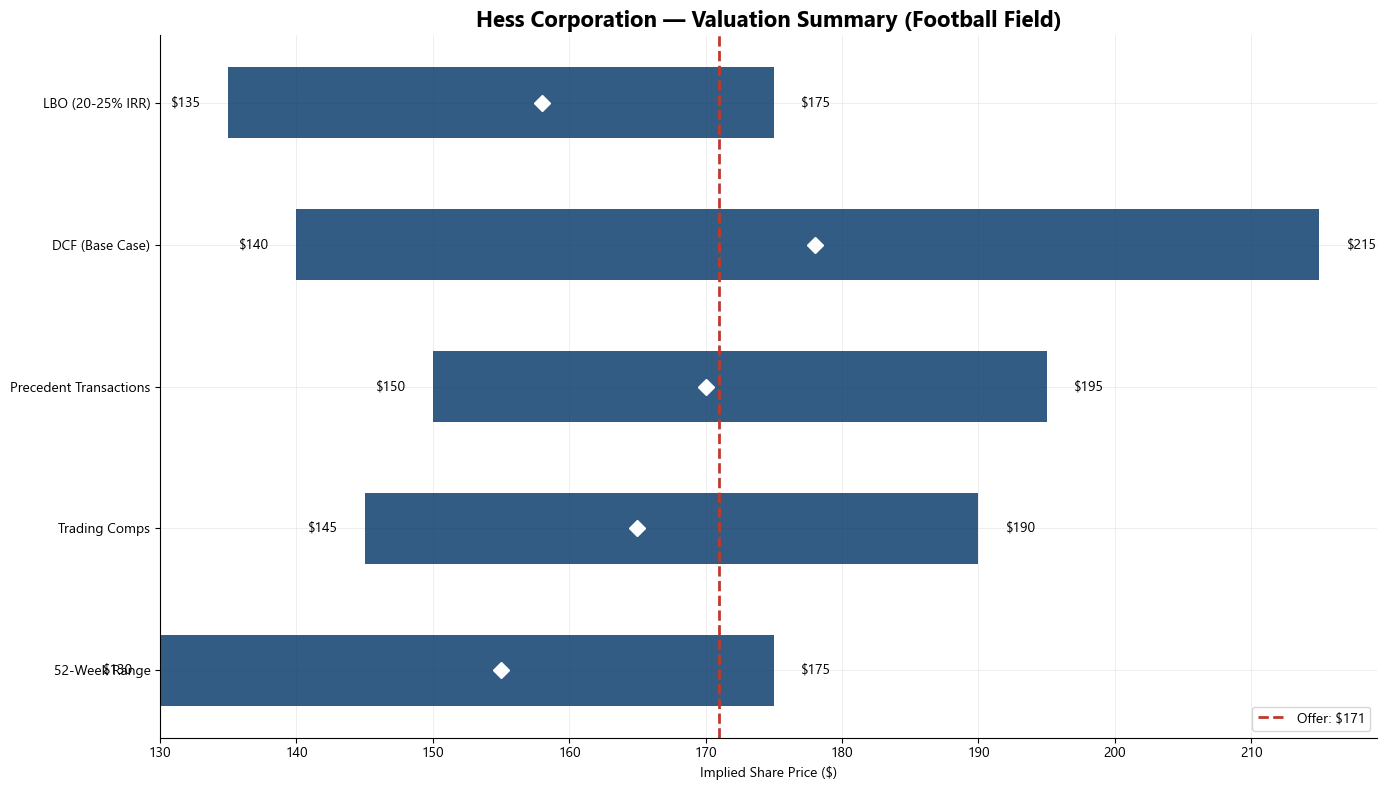

In [3]:
# PLACEHOLDER — Updated in Section 8 after all analyses are computed
placeholder_valuations = {
    '52-Week Range': (130, 155, 175),
    'Trading Comps': (145, 165, 190),
    'Precedent Transactions': (150, 170, 195),
    'DCF (Base Case)': (140, 178, 215),
    'LBO (20-25% IRR)': (135, 158, 175),
}

fig = plot_football_field(placeholder_valuations, DEAL_TERMS['implied_price'],
                          'Hess Corporation — Valuation Summary (Football Field)')
plt.show()

> **Note:** The football field chart above is a preliminary summary. Each methodology is detailed in subsequent sections. The final comprehensive football field appears in Section 8.

---